<a href="https://colab.research.google.com/github/BU-Spark/ds-ciss-predictive-homlessness/blob/data-cleaning-feature/QihangReal539.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

# 1. Load data
df = pd.read_csv('/content/CISS_final_df2.csv')

In [ ]:
# 2. Data exploration
print("Dataset Basic Information:")
print(f"Dataset shape: {df.shape}")
print("\nFirst 5 rows of dataset:")
print(df.head())

print("\nStatistical description:")
print(df.describe())

print("\nMissing values count:")
print(df.isnull().sum())


Dataset Basic Information:
Dataset shape: (6386, 18)

First 5 rows of dataset:
  CoC_Number  Year  weighted median income  weighted median rent  \
0     AK-500  2007            78328.533122           1062.638009   
1     AK-500  2008            78328.533122           1062.638009   
2     AK-500  2009            78328.533122           1062.638009   
3     AK-500  2010            78328.533122           1062.638009   
4     AK-500  2011            80808.699781           1037.436470   

   total population       CoC Name  Overall Homeless  \
0          284267.0  Anchorage CoC          3.426356   
1          284267.0  Anchorage CoC          3.598729   
2          284267.0  Anchorage CoC          4.457077   
3          284267.0  Anchorage CoC          4.330436   
4          287390.0  Anchorage CoC          4.255541   

   Sheltered Total Homeless  Unsheltered Homeless  \
0                  2.962004              0.464352   
1                  3.239912              0.358818   
2               

<Figure size 1200x800 with 0 Axes>

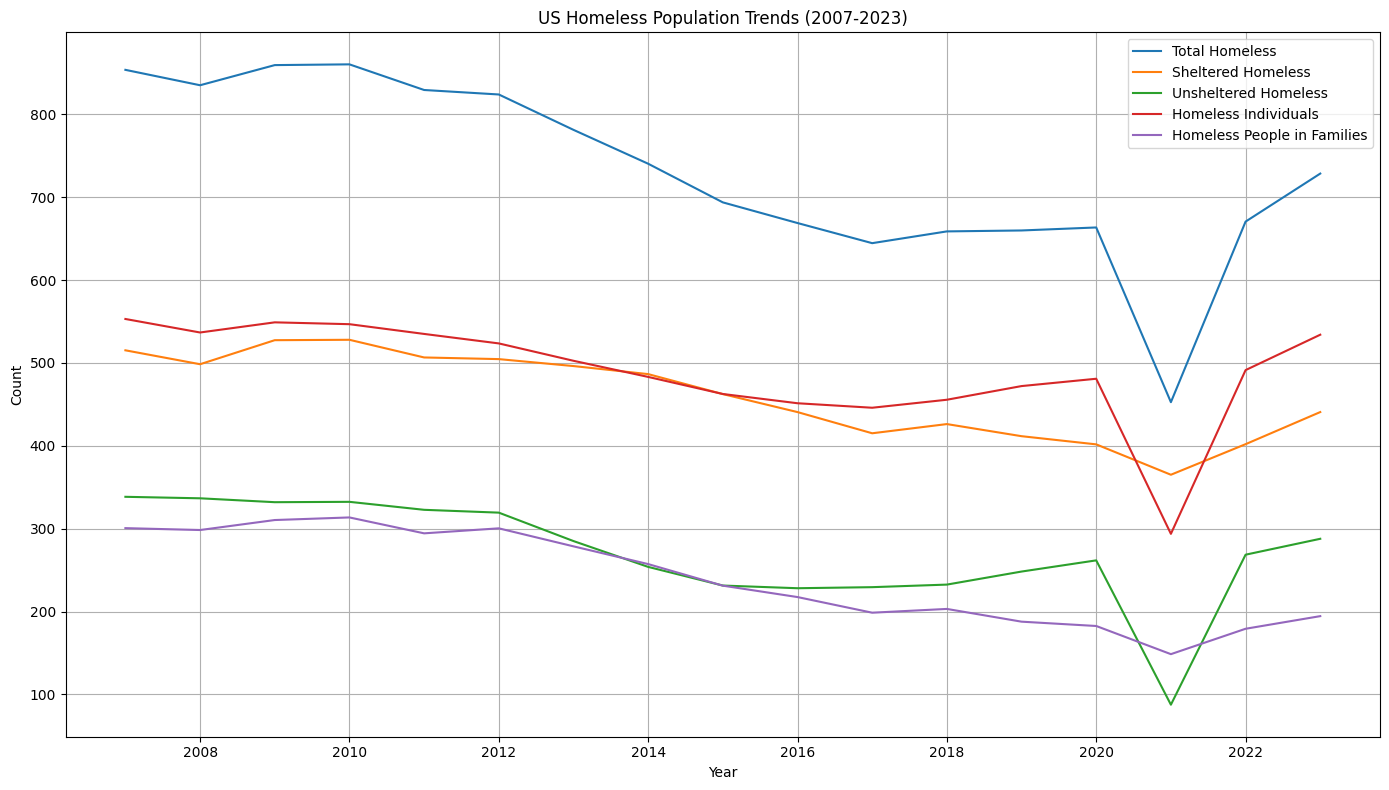

In [ ]:
# 3. Data visualization

# 3.1 Homeless population trends
plt.figure(figsize=(12, 8))
yearly_data = df.groupby('Year').agg({
    'Overall Homeless': 'sum',
    'Sheltered Total Homeless': 'sum',
    'Unsheltered Homeless': 'sum',
    'Overall Homeless Individuals': 'sum',
    'Overall Homeless People in Families': 'sum'
}).reset_index()


plt.figure(figsize=(14, 8))
plt.plot(yearly_data['Year'], yearly_data['Overall Homeless'], label='Total Homeless')
plt.plot(yearly_data['Year'], yearly_data['Sheltered Total Homeless'], label='Sheltered Homeless')
plt.plot(yearly_data['Year'], yearly_data['Unsheltered Homeless'], label='Unsheltered Homeless')
plt.plot(yearly_data['Year'], yearly_data['Overall Homeless Individuals'], label='Homeless Individuals')
plt.plot(yearly_data['Year'], yearly_data['Overall Homeless People in Families'], label='Homeless People in Families')
plt.xlabel('Year')
plt.ylabel('Count')
plt.title('US Homeless Population Trends (2007-2023)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig('homeless_trends.png')

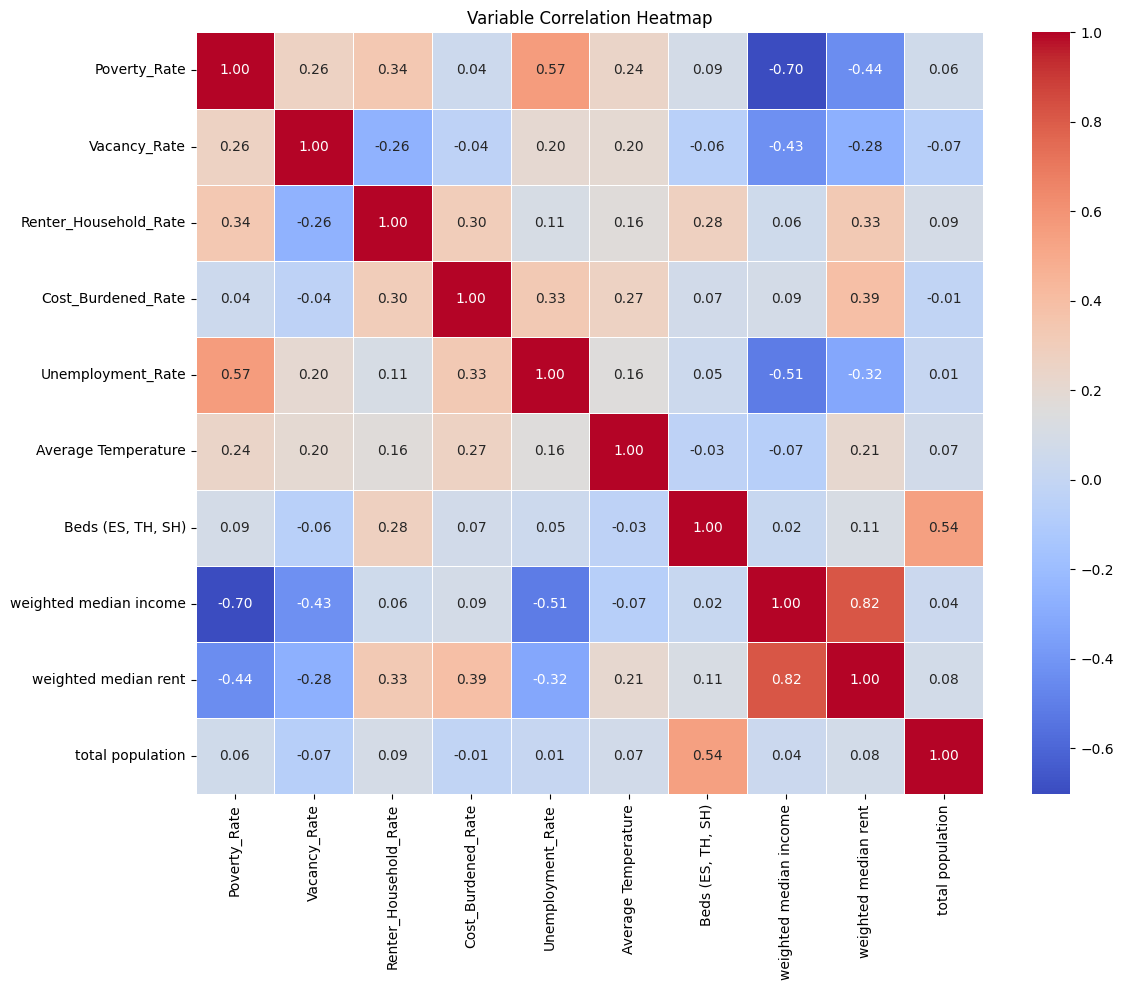

In [ ]:
#Correlation heatmap
corr_columns = ['Poverty_Rate', 'Vacancy_Rate', 'Renter_Household_Rate',
                'Cost_Burdened_Rate', 'Unemployment_Rate', 'Average Temperature',
                'Beds (ES, TH, SH)', 'weighted median income', 'weighted median rent',
                'total population']

corr_matrix = df[corr_columns].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Variable Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')


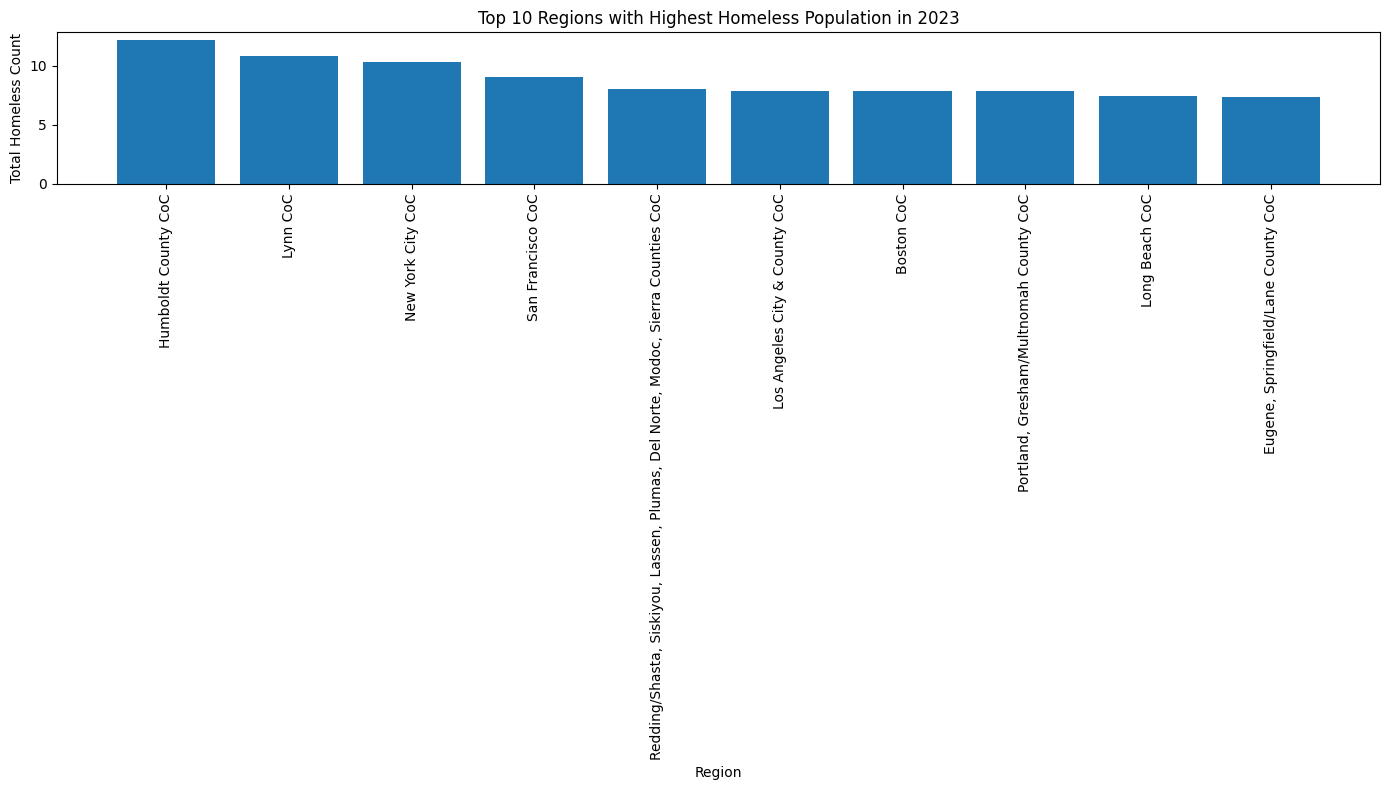

In [ ]:
# 3.4 Regions with highest homeless population (based on latest year data)
latest_year = df['Year'].max()
latest_data = df[df['Year'] == latest_year]
top_regions = latest_data.sort_values('Overall Homeless', ascending=False).head(10)

plt.figure(figsize=(14, 8))
plt.bar(top_regions['CoC Name'], top_regions['Overall Homeless'])
plt.xticks(rotation=90)
plt.title(f'Top 10 Regions with Highest Homeless Population in {latest_year}')
plt.xlabel('Region')
plt.ylabel('Total Homeless Count')
plt.tight_layout()
plt.savefig('top_homeless_regions.png')

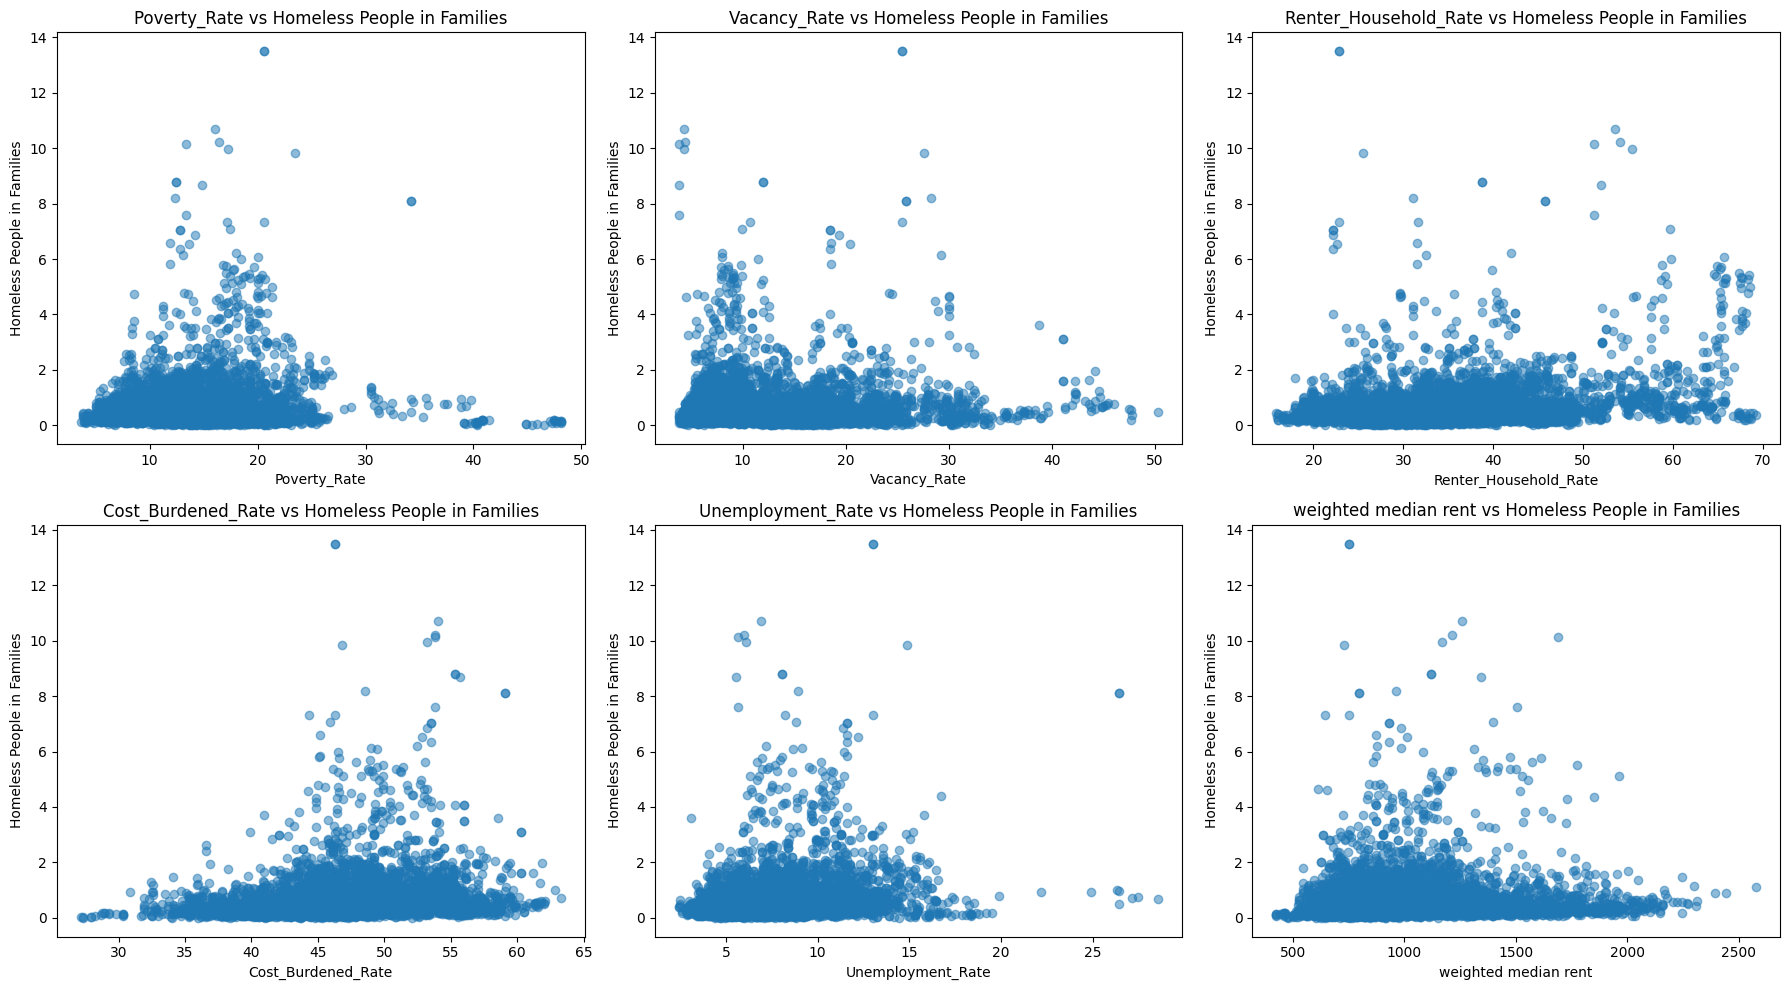

In [ ]:
# 3.5 Scatter plots of socioeconomic factors vs homeless people in families
fig, axs = plt.subplots(2, 3, figsize=(18, 10))
axs = axs.flatten()

socioeconomic_factors = ['Poverty_Rate', 'Vacancy_Rate', 'Renter_Household_Rate',
                         'Cost_Burdened_Rate', 'Unemployment_Rate', 'weighted median rent']

for i, factor in enumerate(socioeconomic_factors):
    axs[i].scatter(df[factor], df['Overall Homeless People in Families'], alpha=0.5)
    axs[i].set_xlabel(factor)
    axs[i].set_ylabel('Homeless People in Families')
    axs[i].set_title(f'{factor} vs Homeless People in Families')

plt.tight_layout()
plt.savefig('socioeconomic_scatter.png')


目标变量缺失值统计：
Overall Homeless People in Families    0
Overall Homeless Individuals           0
Unsheltered Homeless                   0
Sheltered Total Homeless               0
Overall Homeless                       0
dtype: int64


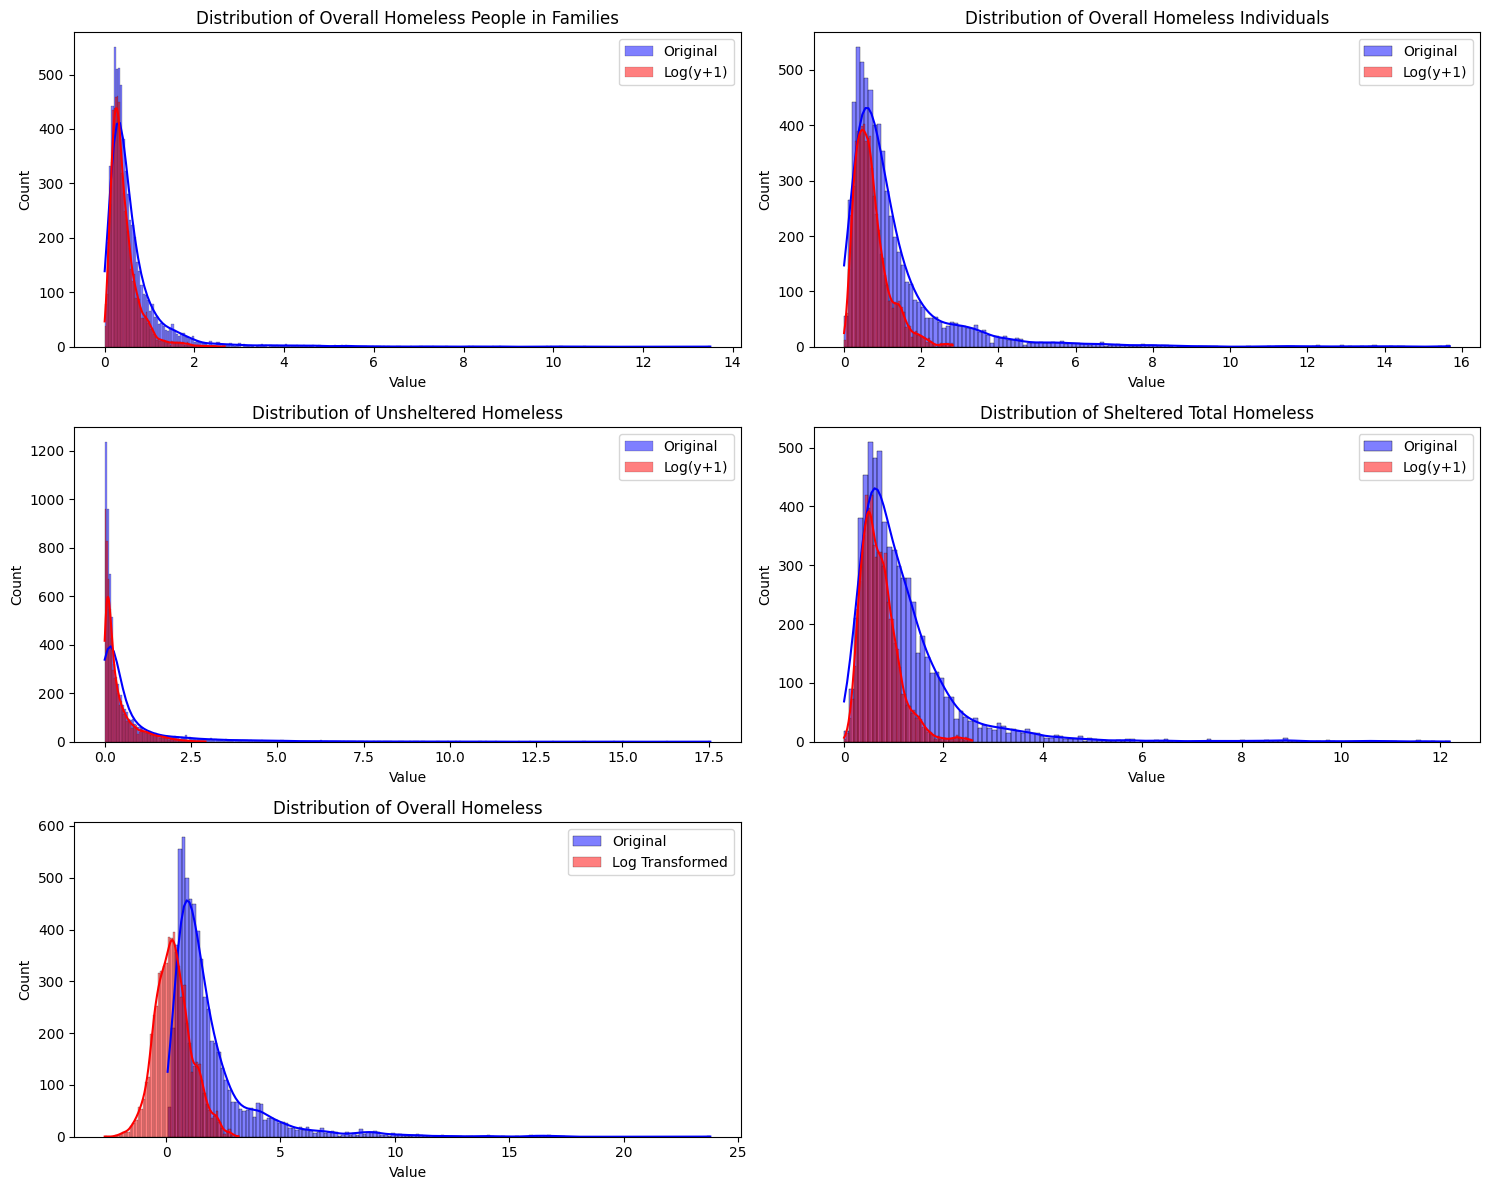


目标变量描述性统计：
       Overall Homeless People in Families  Overall Homeless Individuals  \
count                              6386.00                       6386.00   
mean                                  0.64                          1.30   
std                                   0.84                          1.54   
min                                   0.00                          0.00   
25%                                   0.25                          0.48   
50%                                   0.41                          0.85   
75%                                   0.71                          1.46   
max                                  13.50                         15.69   

       Unsheltered Homeless  Sheltered Total Homeless  Overall Homeless  
count               6386.00                   6386.00           6386.00  
mean                   0.72                      1.23              1.95  
std                    1.45                      1.19              2.04  
min    

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# 2. 定义目标变量列表
target_columns = [
    "Overall Homeless People in Families",
    "Overall Homeless Individuals",
    "Unsheltered Homeless",
    "Sheltered Total Homeless",
    "Overall Homeless"
]

# 3. 检查数据是否存在缺失值
print("目标变量缺失值统计：")
print(df[target_columns].isnull().sum())

# 4. 绘制每个目标变量的分布
plt.figure(figsize=(15, 12))
for i, col in enumerate(target_columns, 1):
    plt.subplot(3, 2, i)

    # 原始数据分布
    sns.histplot(df[col], kde=True, color='blue', label='Original')

    # 对数转换后的分布（处理右偏）
    if (df[col] > 0).all():  # 确保所有值>0才能取对数
        log_transformed = np.log(df[col])
        sns.histplot(log_transformed, kde=True, color='red', label='Log Transformed', alpha=0.5)
    else:
        log_transformed = np.log(df[col] + 1)  # 处理0值
        sns.histplot(log_transformed, kde=True, color='red', label='Log(y+1)', alpha=0.5)

    plt.title(f"Distribution of {col}")
    plt.xlabel("Value")
    plt.legend()
plt.tight_layout()
plt.show()

# 5. 输出描述性统计
print("\n目标变量描述性统计：")
print(df[target_columns].describe().round(2))

# 6. 偏态分析（正偏态 > 0 表示右偏，负偏态 < 0 表示左偏）
print("\n目标变量偏态系数：")
print(df[target_columns].skew().round(2))

In [ ]:
 #4.1 Data preprocessing
# Select features
features = ['Poverty_Rate', 'Vacancy_Rate', 'Renter_Household_Rate',
           'Cost_Burdened_Rate', 'Unemployment_Rate', 'Average Temperature',
           'Beds (ES, TH, SH)', 'weighted median income', 'weighted median rent',
           'total population', 'Year']

# Drop missing values
clean_df = df.dropna(subset=features + ['Overall Homeless People in Families'])

# Split features and target variable
X = clean_df[features]
y = clean_df['Overall Homeless People in Families']

# Handle missing Temperature values (if any)
if X['Average Temperature'].isna().any():
    X['Average Temperature'] = X['Average Temperature'].fillna(X['Average Temperature'].mean())

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
# 4.2 Build neural network model
def build_nn_model():
    model = Sequential([
        Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)  # Output layer
    ])

    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

# Initialize model
nn_model = build_nn_model()

# Early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)


Epoch 1/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.2521 - mae: 0.2756 - val_loss: 0.2219 - val_mae: 0.2581
Epoch 2/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2084 - mae: 0.2631 - val_loss: 0.2223 - val_mae: 0.2542
Epoch 3/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2213 - mae: 0.2588 - val_loss: 0.2255 - val_mae: 0.2558
Epoch 4/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2148 - mae: 0.2647 - val_loss: 0.2154 - val_mae: 0.2530
Epoch 5/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2738 - mae: 0.2773 - val_loss: 0.2254 - val_mae: 0.2551
Epoch 6/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2588 - mae: 0.2682 - val_loss: 0.2163 - val_mae: 0.2524
Epoch 7/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2157 - mae: 0.2643 - val_loss: 0.2185 - val_mae: 0.2539
Epoch 8/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2176 - mae: 0.2727 - val_loss: 0.2177 - val_mae: 0.2593
Epoch 9/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/

Text(0.5, 0, 'Epoch')

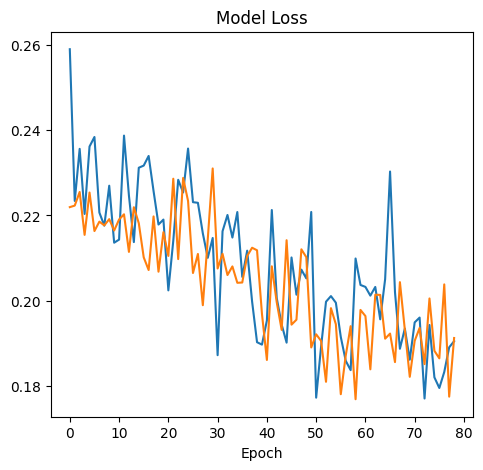

In [ ]:
# 4.3 Compile and train the model
nn_model.compile(optimizer='adam', loss='mse', metrics=['mae'])  # Track MAE
history = nn_model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

# 4.4 Evaluate the model
y_pred = nn_model.predict(X_test_scaled).flatten()

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)  # Calculate MAE

print("\nNeural Network Model Evaluation:")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R²): {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")  # Print MAE

# 4.5 Visualize training process
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')

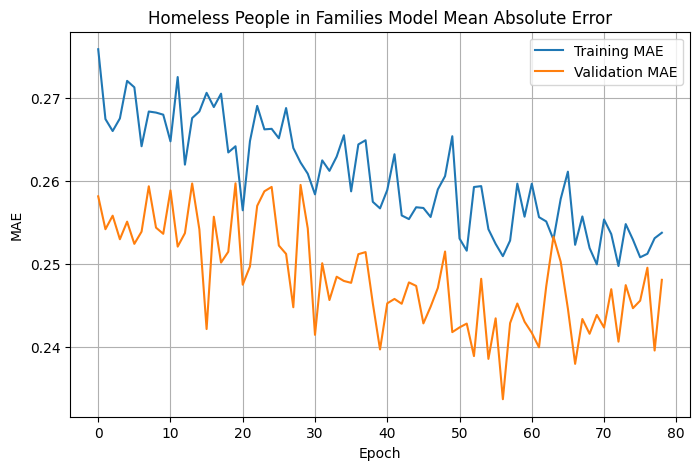

In [ ]:
# 4.5 Visualize MAE
plt.figure(figsize=(8, 5))
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Homeless People in Families Model Mean Absolute Error')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)
plt.savefig('mae_history.png')



Training model for: Overall Homeless Individuals
Epoch 1/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 3.8929 - mae: 1.0584 - val_loss: 1.9169 - val_mae: 0.6511
Epoch 2/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2.3113 - mae: 0.7370 - val_loss: 1.7443 - val_mae: 0.6414
Epoch 3/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2.1352 - mae: 0.7131 - val_loss: 1.6611 - val_mae: 0.6077
Epoch 4/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2.1435 - mae: 0.7231 - val_loss: 1.5466 - val_mae: 0.6072
Epoch 5/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.7507 - mae: 0.6751 - val_loss: 1.4696 - val_mae: 0.6170
Epoch 6/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.9396 - mae: 0.6872 - val_loss: 1.4104 - val_mae: 0.5801
Epoch 7/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.7805 - mae: 0.6874 - val_loss: 1.3888 - val_mae: 0.6001
Epoch 8/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.7581 - mae: 0.6780 - val_loss: 1.3104 - val_mae: 0.564

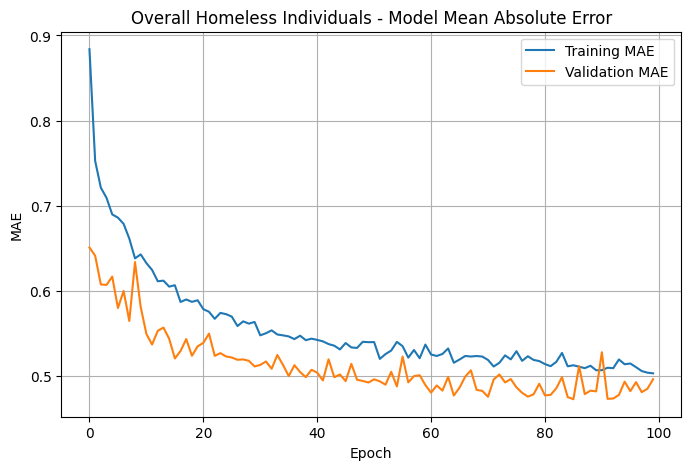

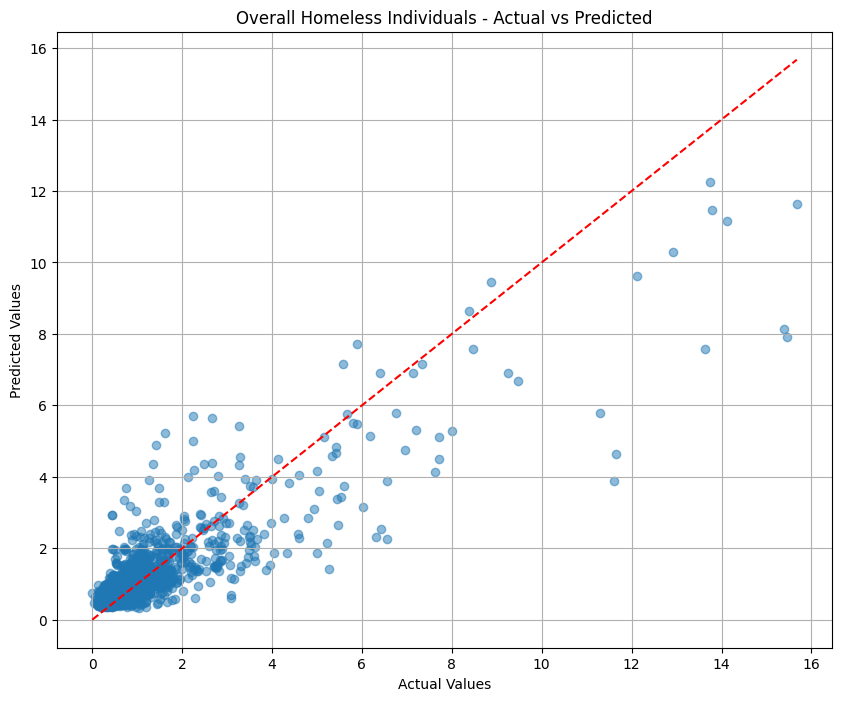

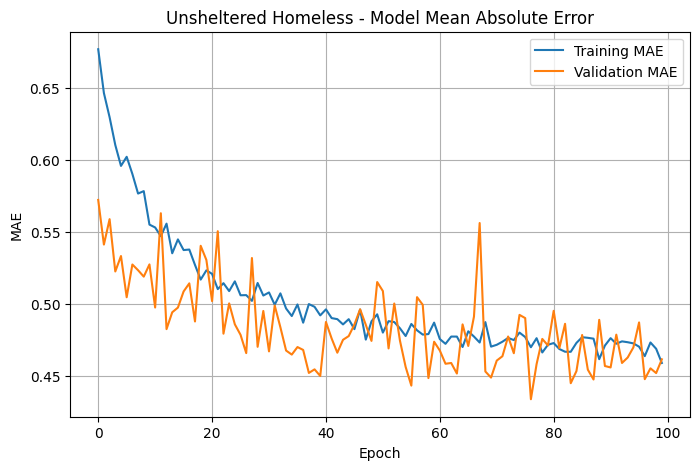

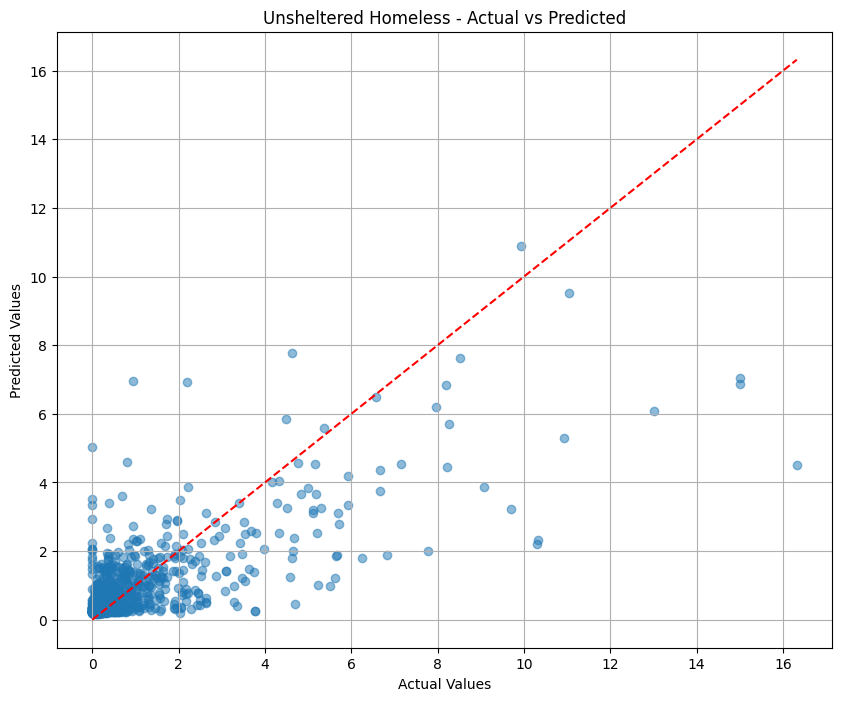

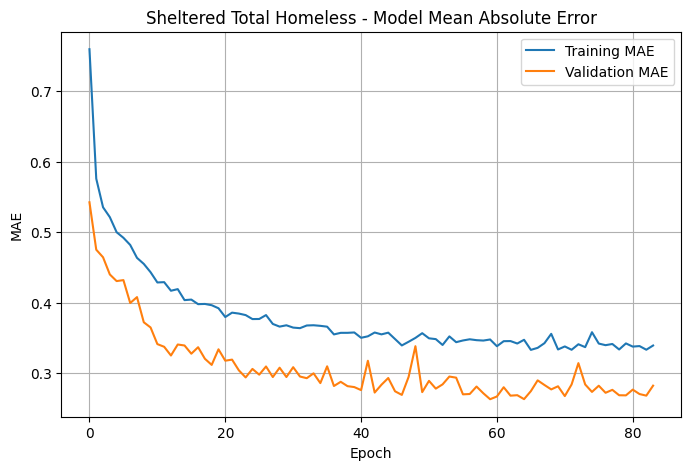

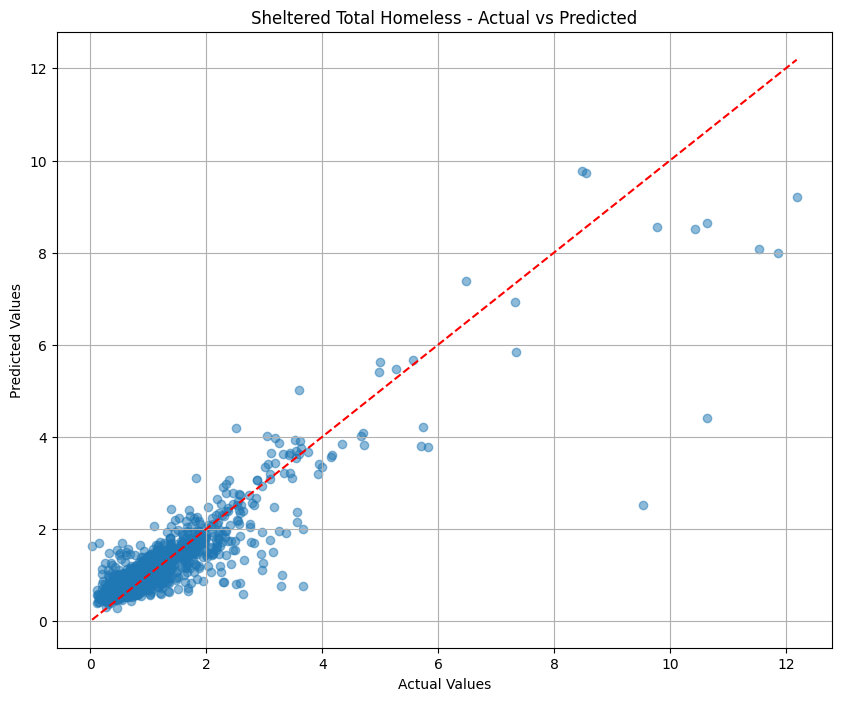

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

def preprocess_data(target_variable, df):
    """
    Preprocess data for a specific target variable
    """
    # Select features
    features = ['Poverty_Rate', 'Vacancy_Rate', 'Renter_Household_Rate',
               'Cost_Burdened_Rate', 'Unemployment_Rate', 'Average Temperature',
               'Beds (ES, TH, SH)', 'weighted median income', 'weighted median rent',
               'total population', 'Year']

    # Drop missing values
    clean_df = df.dropna(subset=features + [target_variable])

    # Split features and target variable
    X = clean_df[features]
    y = clean_df[target_variable]

    # Handle missing Temperature values (if any)
    if X['Average Temperature'].isna().any():
        X['Average Temperature'] = X['Average Temperature'].fillna(X['Average Temperature'].mean())

    return X, y

def build_nn_model(input_shape, regularization_rate=0.01):
    """
    Build a neural network model with regularization
    """
    model = Sequential([
        Dense(64, activation='relu', input_shape=(input_shape,), kernel_regularizer=l2(regularization_rate)),
        Dropout(0.2),
        Dense(32, activation='relu', kernel_regularizer=l2(regularization_rate)),
        Dropout(0.2),
        Dense(16, activation='relu', kernel_regularizer=l2(regularization_rate)),
        Dense(1)  # Output layer
    ])

    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

def train_and_evaluate_model(target_variable, df):
    """
    Train and evaluate a model for a specific target variable without K-fold cross-validation
    """
    print(f"\n{'='*60}")
    print(f"Training model for: {target_variable}")
    print(f"{'='*60}")

    # Preprocess data
    X, y = preprocess_data(target_variable, df)

    # Split into training and test sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Feature standardization
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Build and train model
    model = build_nn_model(X_train_scaled.shape[1])
    early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

    history = model.fit(
        X_train_scaled, y_train,
        epochs=100,
        batch_size=32,
        validation_split=0.2,
        callbacks=[early_stopping],
        verbose=1
    )

    # Evaluate on test set
    y_pred = model.predict(X_test_scaled).flatten()

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    # Print results
    print("\nFinal model evaluation on test set:")
    print(f"Mean Squared Error (MSE): {mse:.2f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"Mean Absolute Error (MAE): {mae:.2f}")
    print(f"R-squared (R²): {r2:.4f}")

    # Visualize MAE
    plt.figure(figsize=(8, 5))
    plt.plot(history.history['mae'], label='Training MAE')
    plt.plot(history.history['val_mae'], label='Validation MAE')
    plt.title(f'{target_variable} - Model Mean Absolute Error')
    plt.xlabel('Epoch')
    plt.ylabel('MAE')
    plt.legend()
    plt.grid(True)
    plt.savefig(f'{target_variable.replace(" ", "_")}_mae_history.png')

    # Error analysis plot (predicted vs actual)
    plt.figure(figsize=(10, 8))
    plt.scatter(y_test, y_pred, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(f'{target_variable} - Actual vs Predicted')
    plt.grid(True)
    plt.savefig(f'{target_variable.replace(" ", "_")}_actual_vs_predicted.png')

    # Return final model and metrics
    return model, history, {'mse': mse, 'rmse': rmse, 'r2': r2, 'mae': mae}

# 5. Train models for each target variable
# 5.1 Overall Homeless Individuals
model1, history1, metrics1 = train_and_evaluate_model('Overall Homeless Individuals', df)

# 5.2 Unsheltered Homeless
model2, history2, metrics2 = train_and_evaluate_model('Unsheltered Homeless', df)

# 5.3 Sheltered Total Homeless
model3, history3, metrics3 = train_and_evaluate_model('Sheltered Total Homeless', df)

# 6. Compare model performances
print("\n" + "="*90)
print("MODEL PERFORMANCE COMPARISON")
print("="*90)
print(f"{'Target Variable':<30} {'RMSE':<15} {'MAE':<15} {'R²':<15}")
print("-"*90)
print(f"{'Overall Homeless Individuals':<30} {metrics1['rmse']:<15.2f} {metrics1['mae']:<15.2f} {metrics1['r2']:<15.4f}")
print(f"{'Unsheltered Homeless':<30} {metrics2['rmse']:<15.2f} {metrics2['mae']:<15.2f} {metrics2['r2']:<15.4f}")
print(f"{'Sheltered Total Homeless':<30} {metrics3['rmse']:<15.2f} {metrics3['mae']:<15.2f} {metrics3['r2']:<15.4f}")
print("="*90)


Training model for: Overall Homeless
Epoch 1/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 6.8160 - mae: 1.5688 - val_loss: 2.9897 - val_mae: 0.8703
Epoch 2/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.3516 - mae: 1.1137 - val_loss: 2.7662 - val_mae: 0.8218
Epoch 3/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.4443 - mae: 0.9776 - val_loss: 2.5898 - val_mae: 0.8163
Epoch 4/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3.2970 - mae: 0.9909 - val_loss: 2.5110 - val_mae: 0.8218
Epoch 5/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2.9442 - mae: 0.9203 - val_loss: 2.3650 - val_mae: 0.8227
Epoch 6/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 3.0080 - mae: 0.9470 - val_loss: 2.2601 - val_mae: 0.7989
Epoch 7/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2.8621 - mae: 0.9172 - val_loss: 2.2259 - val_mae: 0.7722
Epoch 8/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2.6726 - mae: 0.9028 - val_loss: 2.1357 - val_mae: 0.7923
Epoch 9/1

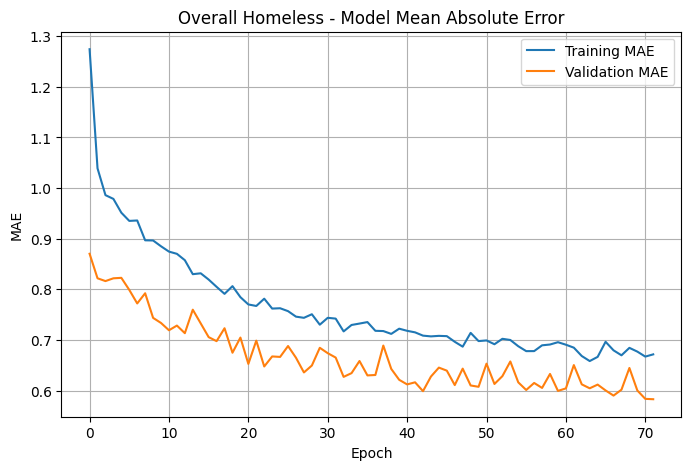

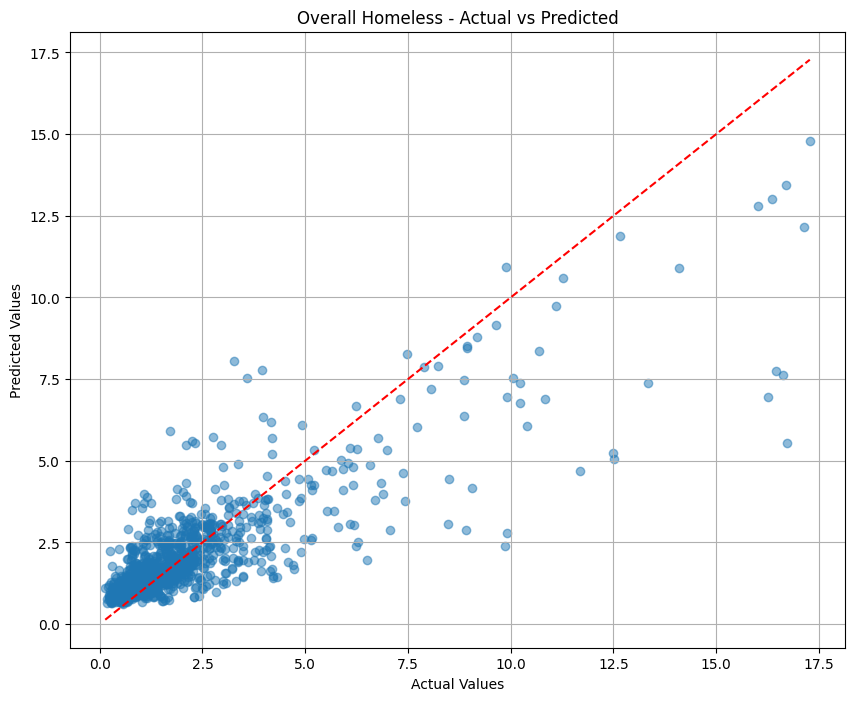

In [ ]:
# 5.4 Overall Homeless
model4, history4, metrics4 = train_and_evaluate_model('Overall Homeless',df)

print("\n" + "="*90)
print("MODEL PERFORMANCE COMPARISON")
print("="*90)
print(f"{'Target Variable':<30} {'RMSE':<15} {'MAE':<15} {'R²':<15}")
print("-"*90)
print(f"{'Overall Homeless Individuals':<30} {metrics1['rmse']:<15.2f} {metrics1['mae']:<15.2f} {metrics1['r2']:<15.4f}")
print(f"{'Unsheltered Homeless':<30} {metrics2['rmse']:<15.2f} {metrics2['mae']:<15.2f} {metrics2['r2']:<15.4f}")
print(f"{'Sheltered Total Homeless':<30} {metrics3['rmse']:<15.2f} {metrics3['mae']:<15.2f} {metrics3['r2']:<15.4f}")
print("="*90)